# Travel Insurance: Claim Prediction
### Created By : Rico Reswara, Alessandro Nicho Hutahaean, Daniel Tirta Pratama, Muhammad Adiel Faeyza

## Business Problem Understanding

**Context**  
Sebuah perusahaan asuransi perjalanan (Travel Insurance) ingin memprediksi apakah seorang pemegang polis asuransi akan mengajukan klaim atau tidak selama perjalanan mereka. Informasi terkait agen asuransi, jenis agensi, saluran distribusi, nama produk, durasi perjalanan, tujuan, nilai penjualan, komisi, usia, dan jenis kelamin tersedia dari histori nasabah di masa lalu.

Target :

No / 0 : Tidak mengajukan klaim

Yes / 1 : Mengajukan klaim

**Problem Statement :**

Proses pengelolaan dana dan risiko asuransi bisa menjadi tidak efisien jika perusahaan tidak dapat memperkirakan seberapa banyak klaim yang akan diajukan oleh nasabahnya. Perusahaan ingin meningkatkan efisiensi finansial dan penentuan harga premi (pricing) dengan mengetahui profil kandidat mana yang memiliki probabilitas tinggi untuk mengajukan klaim asuransi perjalanan.

Jika perusahaan tidak dapat memprediksi klaim dengan baik, perusahaan bisa mengalami kerugian finansial yang mendadak atau mengalokasikan cadangan dana yang berlebihan sehingga tidak efisien.

**Goals :**

Berdasarkan permasalahan tersebut, perusahaan ingin memiliki kemampuan untuk memprediksi kemungkinan seorang nasabah akan mengajukan klaim atau tidak. Hal ini bertujuan untuk mengelola risiko finansial, menyesuaikan harga premi berdasarkan risiko nasabah, dan mengalokasikan cadangan dana klaim yang lebih akurat.

Perusahaan juga ingin mengetahui faktor/variabel apa yang paling memengaruhi seorang nasabah dalam mengajukan klaim, sehingga mereka dapat membuat strategi bisnis yang lebih baik ke depannya.

**Analytic Approach :**

Kita akan menganalisis data untuk menemukan pola yang membedakan nasabah yang mengajukan klaim (Yes) dan yang tidak (No).

Kemudian kita akan membangun model klasifikasi *Machine Learning* yang akan membantu perusahaan untuk dapat memprediksi probabilitas seorang nasabah akan mengajukan klaim asuransi atau tidak.

**Metric Evaluation**

Type 1 error : False Positive (Model memprediksi Klaim, padahal Tidak Klaim)
Konsekuensi: Perusahaan mengalokasikan dana cadangan yang tidak perlu dan mungkin memberikan harga premi yang terlalu mahal, sehingga bisa kehilangan daya saing di pasar.

Type 2 error : False Negative (Model memprediksi Tidak Klaim, padahal Klaim)
Konsekuensi: Perusahaan tidak menyiapkan dana cadangan untuk klaim tersebut, yang dapat menyebabkan kerugian finansial mendadak dan mengganggu likuiditas perusahaan.

Berdasarkan konsekuensinya, *False Negative* sangat berbahaya bagi kestabilan finansial asuransi. Namun, karena dataset asuransi biasanya sangat tidak seimbang (*imbalanced* – jumlah klaim jauh lebih sedikit dari yang tidak klaim), metrik utama yang akan kita gunakan adalah **ROC_AUC** untuk melihat performa model secara keseluruhan dalam membedakan kelas, serta memperhatikan nilai **Recall** untuk kelas positif.

## Data Understanding

Note :
- Dataset kemungkinan besar tidak seimbang (Imbalanced)
- Terdapat beberapa fitur kategorikal dan numerikal.
- Setiap baris data merepresentasikan informasi satu polis asuransi perjalanan.

### Attribute Information

Berikut adalah penjelasan setiap kolom (fitur) yang terdapat dalam dataset Travel Insurance:

| Attribute | Data Type | Description |
|---|---|---|
| Agency | Categorical (Nominal) | Kode nama agen asuransi yang menjual polis. Terdapat 16 agen unik (contoh: EPX, C2B, JWT, CWT) |
| Agency Type | Categorical (Nominal) | Jenis agen: **Travel Agency** atau **Airlines** |
| Distribution Channel | Categorical (Nominal) | Saluran penjualan polis: **Online** atau **Offline** |
| Product Name | Categorical (Nominal) | Nama produk asuransi perjalanan yang dibeli nasabah (26 produk unik) |
| Gender | Categorical (Nominal) | Jenis kelamin nasabah: **M** (Male) atau **F** (Female). Kolom ini memiliki **71.39% missing value** karena pengisian bersifat opsional saat pendaftaran |
| Duration | Numerical (Continuous) | Durasi perjalanan dalam satuan **hari** |
| Destination | Categorical (Nominal) | Negara tujuan perjalanan nasabah (138 negara unik) |
| Net Sales | Numerical (Continuous) | Nilai premi bersih yang dibayarkan oleh nasabah (dalam satuan mata uang lokal). Dapat bernilai negatif untuk kasus refund/pembatalan |
| Commision (in value) | Numerical (Continuous) | Nilai komisi yang diterima oleh agen asuransi dari penjualan polis |
| Age | Numerical (Discrete) | Usia nasabah dalam satuan tahun |
| **Claim** | **Target — Binary** | **0 (No)**: Nasabah tidak mengajukan klaim \| **1 (Yes)**: Nasabah mengajukan klaim selama perjalanan |

**Catatan penting:**
- Dataset ini sangat **imbalanced**: hanya sekitar 1.5% (677 dari 44.328) nasabah yang mengajukan klaim
- Kolom `Gender` memiliki missing value terbanyak (71.39%), sementara kolom lainnya tidak memiliki missing value
- Setiap baris data merepresentasikan satu transaksi penjualan polis asuransi perjalanan

In [ ]:
!pip install category_encoders

# Library
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
from IPython.display import display

# Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
import category_encoders as ce

# Model Selection
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import roc_curve, roc_auc_score

# Imbalance Dataset
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Ignore Warning
import sys
import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")

# Set max columns
pd.set_option('display.max_columns', None)

In [ ]:
# Load Dataset
df = pd.read_csv("data_travel_insurance.csv")
df.head()

,Agency,Agency Type,Distribution Channel,Product Name,Gender,Duration,Destination,Net Sales,Commision (in value),Age,Claim
0,C2B,Airlines,Online,Annual Silver Plan,F,365,SINGAPORE,216.0,54.0,57,No
1,EPX,Travel Agency,Online,Cancellation Plan,NaN,4,MALAYSIA,10.0,0.0,33,No
2,JZI,Airlines,Online,Basic Plan,M,19,INDIA,22.0,7.7,26,No
3,EPX,Travel Agency,Online,2 way Comprehensive Plan,NaN,20,UNITED STATES,112.0,0.0,59,No
4,C2B,Airlines,Online,Bronze Plan,M,8,SINGAPORE,16.0,4.0,28,No


In [ ]:
# Count and Datatype for each Column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44328 entries, 0 to 44327
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agency                44328 non-null  object 
 1   Agency Type           44328 non-null  object 
 2   Distribution Channel  44328 non-null  object 
 3   Product Name          44328 non-null  object 
 4   Gender                12681 non-null  object 
 5   Duration              44328 non-null  int64  
 6   Destination           44328 non-null  object 
 7   Net Sales             44328 non-null  float64
 8   Commision (in value)  44328 non-null  float64
 9   Age                   44328 non-null  int64  
 10  Claim                 44328 non-null  object 
dtypes: float64(2), int64(2), object(7)
memory usage: 3.7+ MB


## Data Cleaning

Kita akan melihat apakah ada data yang hilang/kosong pada dataset. Selain itu, mengubah target 'Claim' dari "Yes/No" menjadi 1/0 agar bisa diproses oleh model.

In [ ]:
# Mengubah Target menjadi numerik: Yes = 1, No = 0
df['Claim'] = np.where(df['Claim'] == 'Yes', 1, 0)
df['Claim'].value_counts()

,count
Claim,
0,43651
1,677


Selanjutnya handling untuk data anomali pada dataset

In [ ]:
# 1. Membersihkan anomali pada kolom 'Duration'
# Menghapus durasi negatif
df = df[df['Duration'] >= 0]
median_duration = df['Duration'].median()
df.loc[df['Duration'] > 365, 'Duration'] = median_duration
print(f"\n Duration: hapus negatif & ganti ekstrem (> 365 hari) dengan median ({median_duration:.1f})")


 Duration: hapus negatif & ganti ekstrem (> 365 hari) dengan median (22.0)


In [ ]:
# 2. Membersihkan anomali pada kolom 'Net Sales'
# Cek jika ada refund (Net Sales < 0) tapi status Klaim-nya bernilai 1 (Yes)
anomali = df[(df['Net Sales'] < 0) & (df['Claim'] == 1)].index
df = df.drop(anomali)
df = df[df['Net Sales'] >= 0]
print(f"Net Sales: hapus refund yang klaim ({len(anomali)} baris) & hapus semua Net Sales negatif")


Net Sales: hapus refund yang klaim (0 baris) & hapus semua Net Sales negatif


In [ ]:
# 3. Membersihkan anomali pada kolom 'Age'
# Mencari median dari populasi dengan usia rasional (di bawah 100 tahun)
median_age = df[df['Age'] < 100]['Age'].median()
df['Age'] = df['Age'].apply(lambda v: median_age if v > 100 else v)
print(f"Age: ganti usia > 100 tahun dengan median ({median_age:.1f})")

print(f"\nUkuran data setelah cleaning: {df.shape}")

print("DATA CLEANING - SELESAI")


Age: ganti usia > 100 tahun dengan median (36.0)

Ukuran data setelah cleaning: (43843, 11)
DATA CLEANING - SELESAI


### Pengecekan Data Duplikat

Sebelum melanjutkan proses pembersihan data lebih lanjut, kita perlu memastikan tidak ada baris data yang duplikat. Data duplikat dapat menyebabkan model menjadi *bias* karena informasi yang sama dihitung lebih dari sekali dalam proses pelatihan.

In [ ]:
# Cek data duplikat
print(f"Jumlah data duplikat  : {df.duplicated().sum()}")
print(f"Total baris data      : {len(df)}")
print(f"Jumlah kolom          : {len(df.columns)}")

Jumlah data duplikat  : 4930
Total baris data      : 43843
Jumlah kolom          : 11


Tidak ditemukan data duplikat pada dataset ini. Hal ini wajar karena setiap baris merepresentasikan satu transaksi polis asuransi yang unik, sehingga kita dapat langsung melanjutkan ke tahap analisis berikutnya.

In [ ]:
# Membuat Dataframe Deskriptif persis seperti di referensi
listItem = []
for col in df.columns :
    listItem.append([col, df[col].dtype, df[col].isna().sum(), round((df[col].isna().sum()/len(df[col])) * 100,2),
                    df[col].nunique(), list(df[col].drop_duplicates().sample(2).values)])

dfDesc = pd.DataFrame(columns=['dataFeatures', 'dataType', 'null', 'nullPct', 'unique', 'uniqueSample'],
                     data=listItem)
dfDesc

,dataFeatures,dataType,null,nullPct,unique,uniqueSample
0,Agency,object,0,0.00,16,"[CBH, RAB]"
1,Agency Type,object,0,0.00,2,"[Travel Agency, Airlines]"
2,Distribution Channel,object,0,0.00,2,"[Offline, Online]"
3,Product Name,object,0,0.00,26,"[Silver Plan, Travel Cruise Protect]"
4,Gender,object,31228,71.23,2,"[F, M]"
5,Duration,int64,0,0.00,331,"[201, 25]"
6,Destination,object,0,0.00,137,"[PUERTO RICO, TURKEY]"
7,Net Sales,float64,0,0.00,886,"[4.4, 5.08]"
8,Commision (in value),float64,0,0.00,914,"[1.63, 28.8]"
9,Age,float64,0,0.00,88,"[56.0, 69.0]"


Berikutnya, mari kita visualisasikan *missing values* atau data yang hilang pada dataframe kita dengan menggunakan library `missingno`.

#### Bar Plot

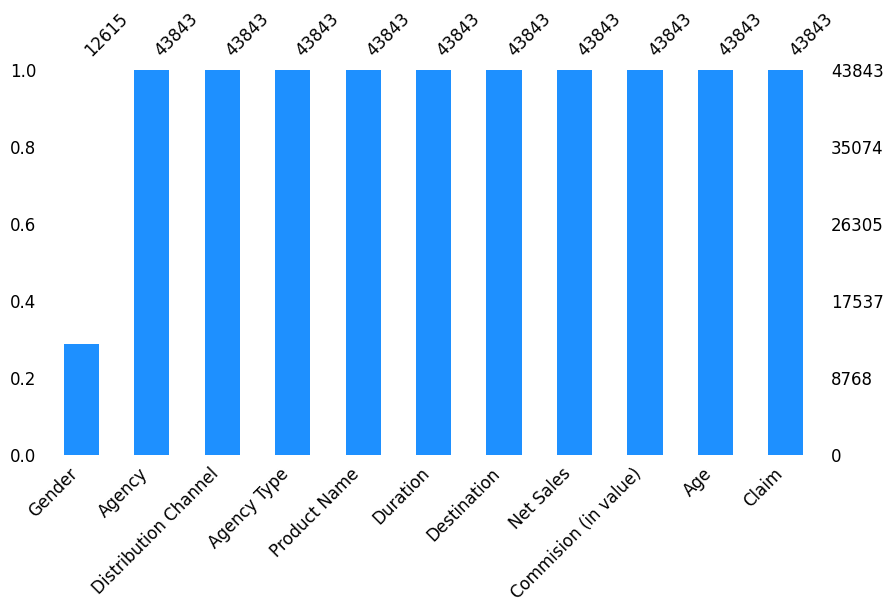

In [ ]:
missingno.bar(df, color="dodgerblue", sort="ascending", figsize=(10,5), fontsize=12);

Terlihat dari Bar Plot tersebut, bahwa kemungkinan besar hanya kolom `Gender` yang memiliki *missing values* yang sangat banyak. Ini sering terjadi karena dalam pengisian form asuransi, *gender* mungkin bersifat opsional atau tidak tercatat.

#### Matrix Plot

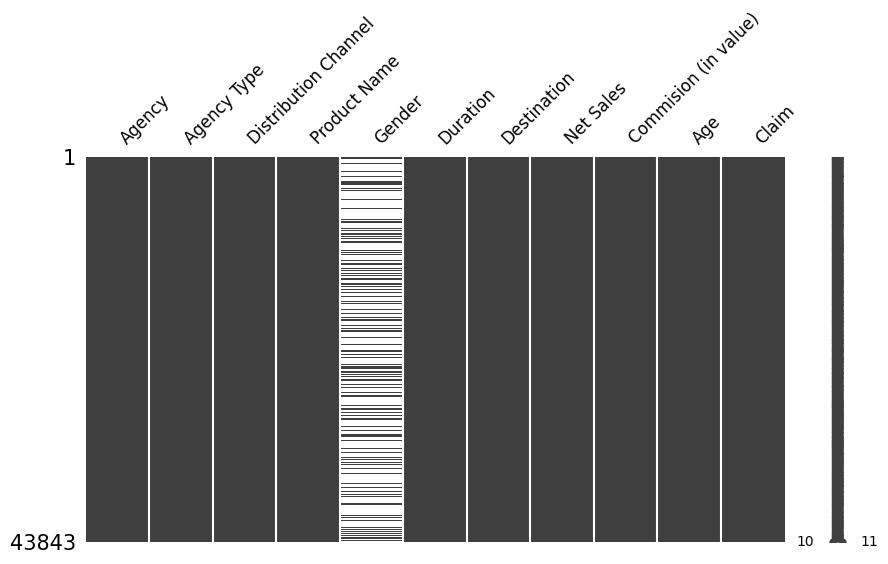

In [ ]:
missingno.matrix(df, figsize=(10,5), fontsize=12);

### Analisis Outlier pada Fitur Numerikal

Untuk fitur numerikal (`Duration`, `Net Sales`, `Commision (in value)`, `Age`), kita perlu mengidentifikasi apakah terdapat nilai ekstrem (*outlier*) yang dapat memengaruhi performa model. Kita gunakan **Boxplot** untuk visualisasi distribusi data.

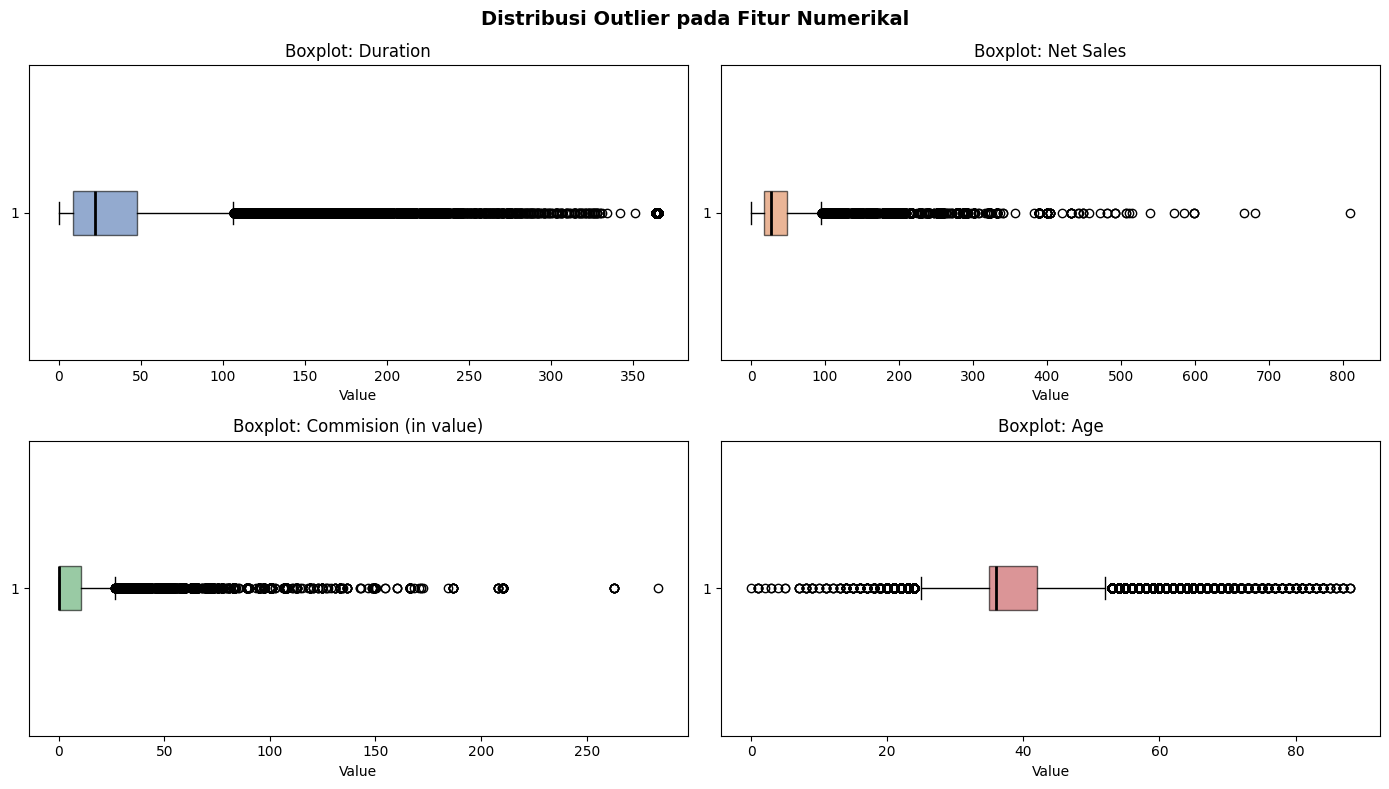


Statistik Deskriptif Fitur Numerikal:


,Duration,Net Sales,Commision (in value),Age
count,43843.000000,43843.000000,43843.000000,43843.000000
mean,40.346760,41.660293,9.551313,38.677075
std,55.076628,47.464800,19.483809,10.016225
min,0.000000,0.000000,0.000000,0.000000
25%,9.000000,18.000000,0.000000,35.000000
50%,22.000000,27.000000,0.000000,36.000000
75%,48.000000,49.000000,10.640000,42.000000
max,365.000000,810.000000,283.500000,88.000000


In [ ]:
# Visualisasi Outlier dengan Boxplot
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
num_features_plot = ['Duration', 'Net Sales', 'Commision (in value)', 'Age']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, color in zip(axes.flatten(), num_features_plot, colors):
    ax.boxplot(df[col].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(f'Boxplot: {col}', fontsize=12)
    ax.set_xlabel('Value')

plt.suptitle('Distribusi Outlier pada Fitur Numerikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Statistik deskriptif
print("\nStatistik Deskriptif Fitur Numerikal:")
display(df[num_features_plot].describe())

**Interpretasi Outlier:**

Dari boxplot di atas, terlihat bahwa:
- **Duration**: Terdapat *outlier* yang sangat ekstrem. Beberapa polis mencatat durasi perjalanan hingga ribuan hari yang kemungkinan adalah polis jangka panjang atau kesalahan input.
- **Net Sales**: Terdapat beberapa nilai negatif (kemungkinan refund/pembatalan polis) dan nilai yang sangat tinggi pada polis premium.
- **Commision (in value)**: Sebagian besar komisi bernilai 0 (agen tanpa komisi/direct), namun ada beberapa nilai sangat tinggi pada produk premium.
- **Age**: Distribusi usia cukup normal, namun terdapat beberapa nilai usia yang tidak realistis (>100 tahun) yang kemungkinan adalah kesalahan input data.

**Penanganan Outlier — Menggunakan RobustScaler:**
Kita memilih **RobustScaler** dibandingkan StandardScaler karena RobustScaler menggunakan **median dan IQR** (bukan mean dan standar deviasi) sehingga tidak terpengaruh oleh nilai ekstrem. Pendekatan ini dipilih karena outlier pada fitur seperti `Duration` mungkin merepresentasikan kasus bisnis yang valid (perjalanan panjang), sehingga kita tidak menghapus data tersebut — hanya melakukan scaling yang robust.

## Exploratory Data Analysis (EDA)
Pada tahap ini, kita dapat melakukan pengecekan korelasi, distribusi durasi perjalanan, perbedaan usia, dan lain sebagainya. (Silakan tambahkan plot korelasi dan distribusi sesuai kebutuhan).

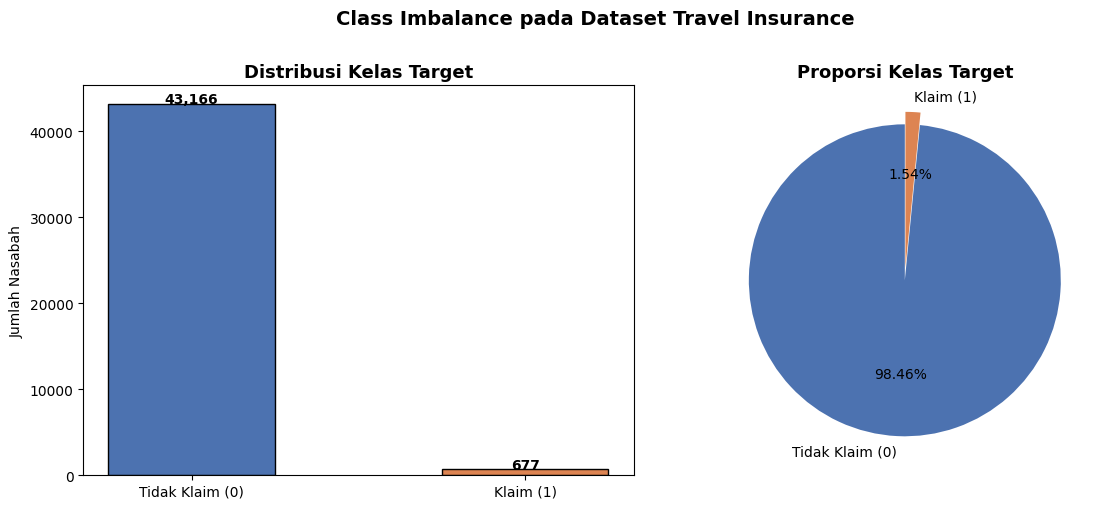

Claim
0    43166
1      677
Name: count, dtype: int64

Rasio kelas: 63.8 : 1 (Tidak Klaim : Klaim)


In [ ]:
# EDA 1: Distribusi Kelas Target (Class Imbalance)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
claim_counts = df['Claim'].value_counts()
axes[0].bar(['Tidak Klaim (0)', 'Klaim (1)'], claim_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Nasabah')
for i, v in enumerate(claim_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(claim_counts.values, labels=['Tidak Klaim (0)', 'Klaim (1)'],
            autopct='%1.2f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance pada Dataset Travel Insurance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(df['Claim'].value_counts())
print(f"\nRasio kelas: {claim_counts[0]/claim_counts[1]:.1f} : 1 (Tidak Klaim : Klaim)")

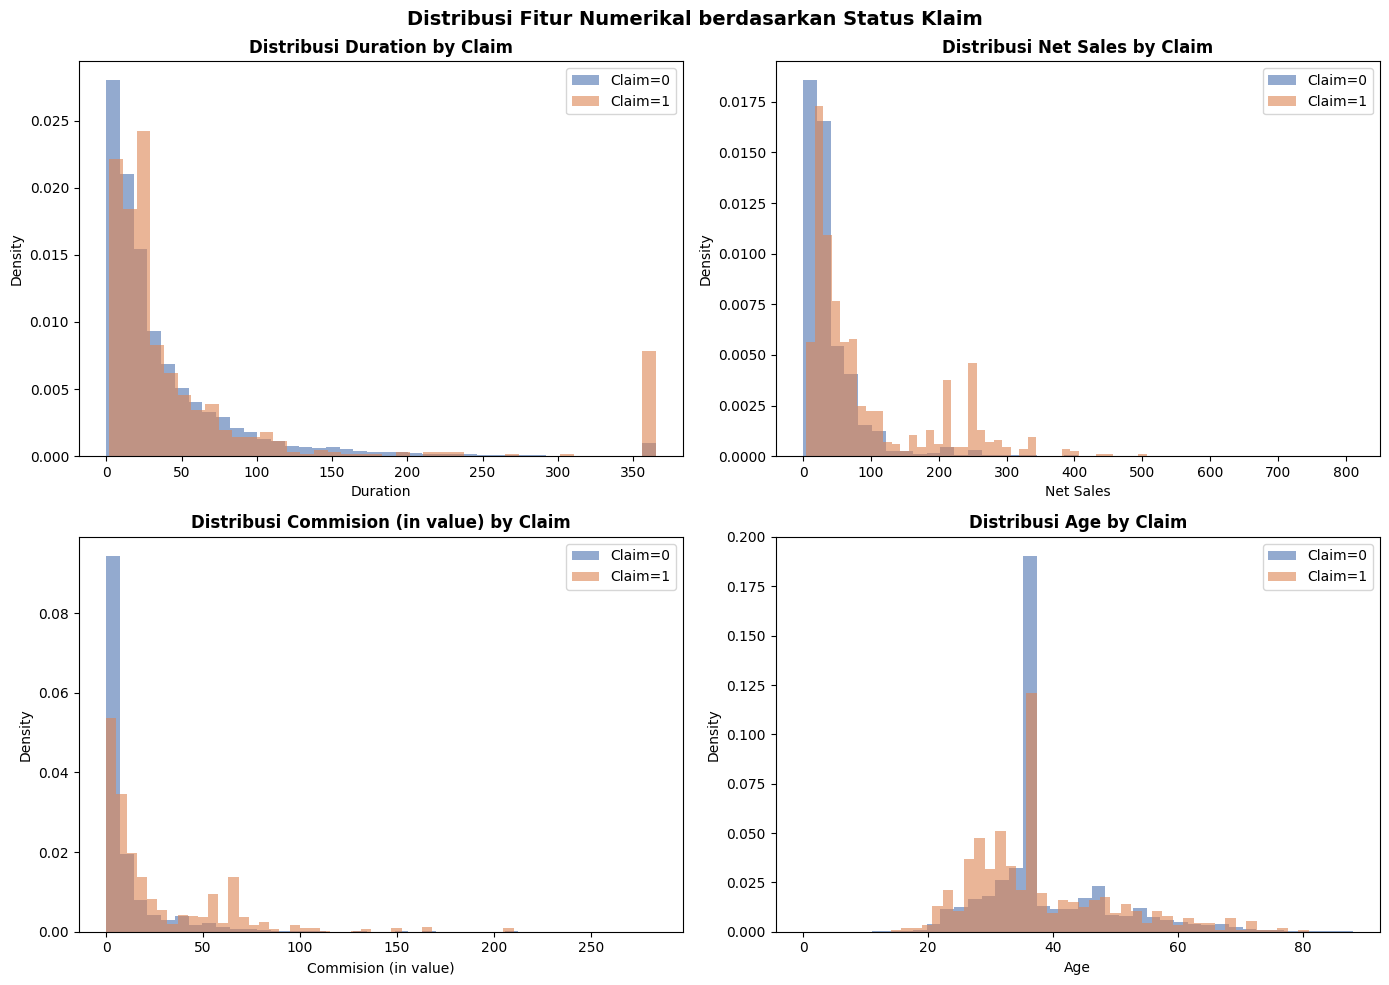

In [ ]:
# EDA 2: Distribusi Fitur Numerikal berdasarkan Kelas
num_features = ['Duration', 'Net Sales', 'Commision (in value)', 'Age']
colors_claim = {0: '#4C72B0', 1: '#DD8452'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), num_features):
    for claim_val, color in colors_claim.items():
        subset = df[df['Claim'] == claim_val][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'Claim={claim_val}', edgecolor='none', density=True)
    ax.set_title(f'Distribusi {col} by Claim', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Distribusi Fitur Numerikal berdasarkan Status Klaim',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

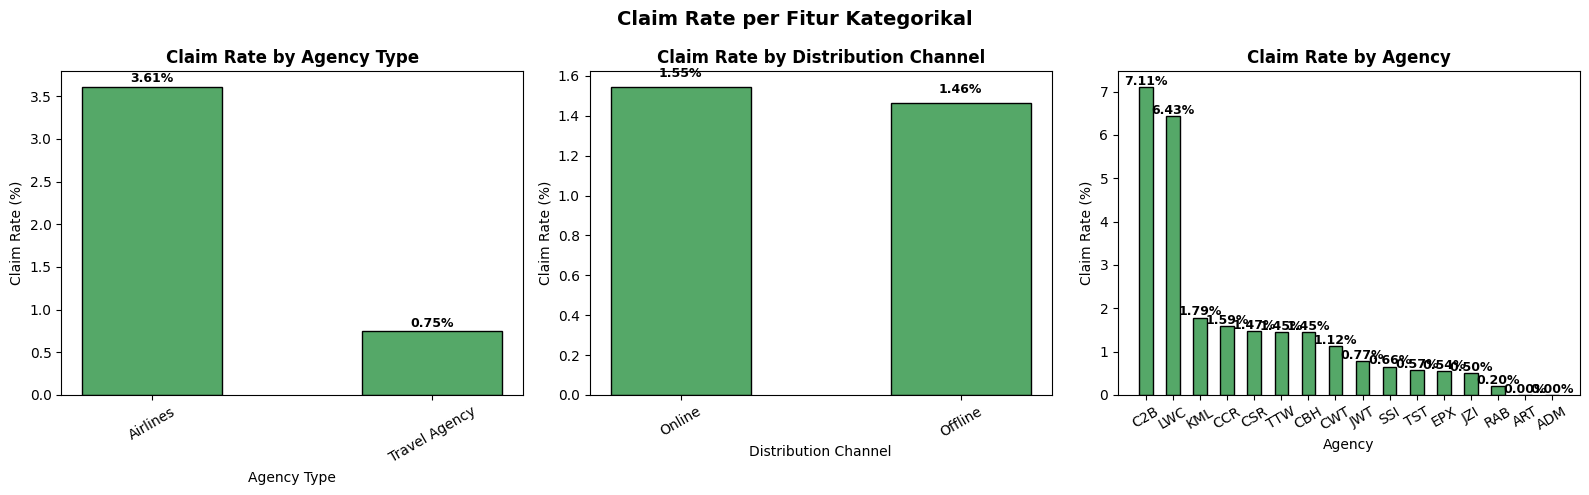

In [ ]:
# EDA 3: Claim Rate per Fitur Kategorikal
cat_features_eda = ['Agency Type', 'Distribution Channel', 'Agency']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, cat_features_eda):
    claim_rate = df.groupby(col)['Claim'].mean().sort_values(ascending=False) * 100
    bars = ax.bar(claim_rate.index, claim_rate.values,
                  color='#55A868', edgecolor='black', width=0.5)
    ax.set_title(f'Claim Rate by {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Claim Rate (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, claim_rate.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.2f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Claim Rate per Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

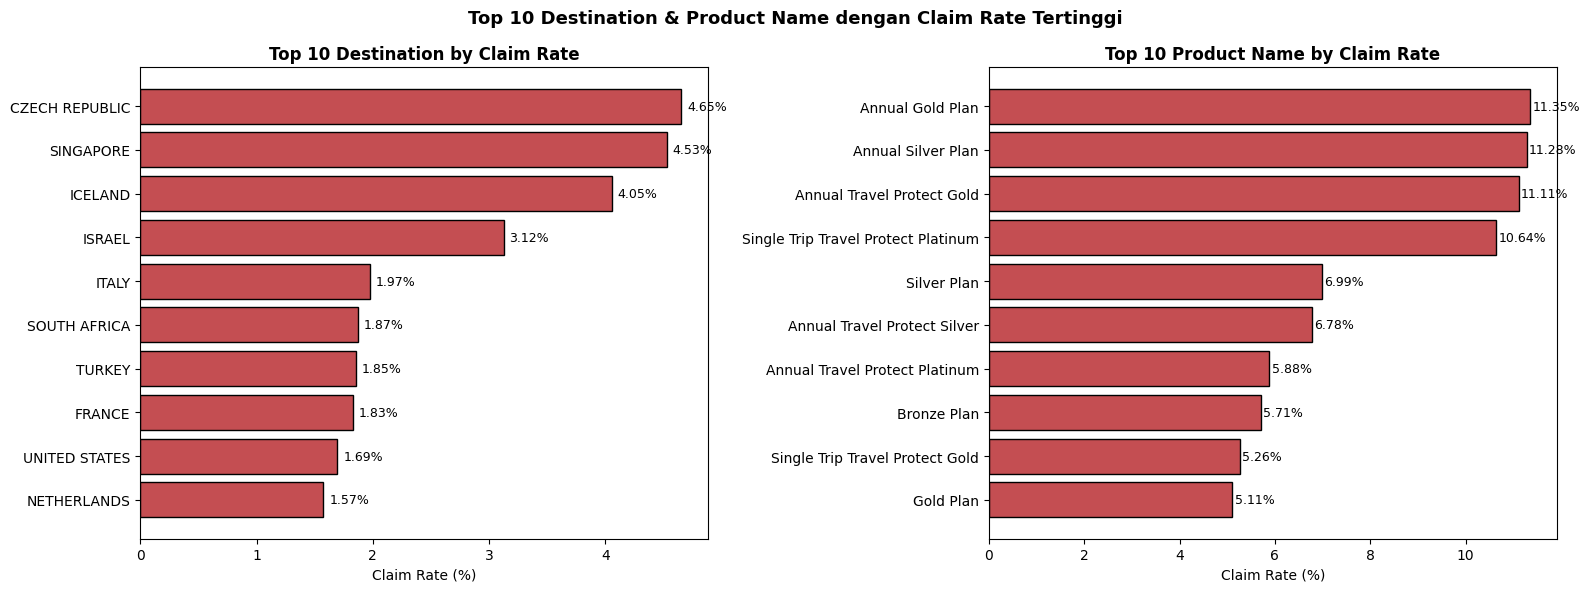

In [ ]:
# EDA 4: Top 10 Destination & Product Name berdasarkan Claim Rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in zip(axes, ['Destination', 'Product Name']):
    # Hanya tampilkan yang jumlah datanya cukup (min 30 baris)
    filtered = df.groupby(col).filter(lambda x: len(x) >= 30)
    claim_rate = filtered.groupby(col)['Claim'].mean().sort_values(ascending=False).head(10) * 100

    bars = ax.barh(claim_rate.index[::-1], claim_rate.values[::-1],
                   color='#C44E52', edgecolor='black')
    ax.set_title(f'Top 10 {col} by Claim Rate', fontsize=12, fontweight='bold')
    ax.set_xlabel('Claim Rate (%)')
    for bar, val in zip(bars, claim_rate.values[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}%', va='center', fontsize=9)

plt.suptitle('Top 10 Destination & Product Name dengan Claim Rate Tertinggi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

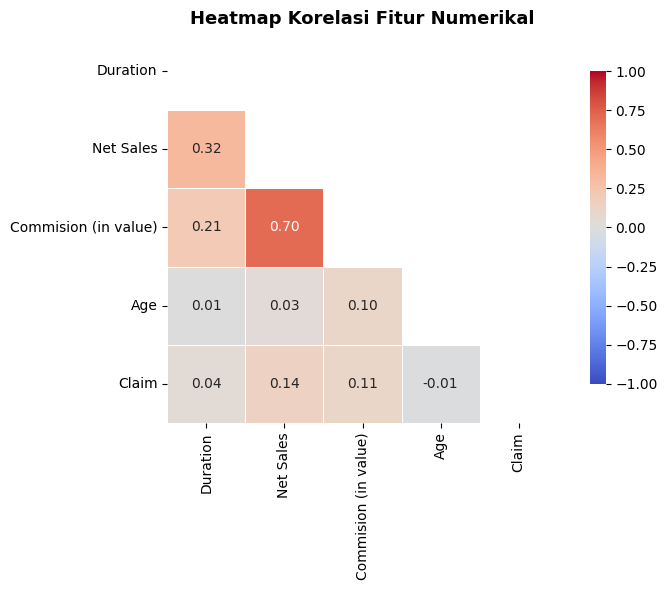


Nilai Korelasi terhadap Target 'Claim':
Claim                   1.000000
Net Sales               0.136950
Commision (in value)    0.105202
Duration                0.042576
Age                    -0.012049


In [ ]:
# EDA 5: Heatmap Korelasi Fitur Numerikal
plt.figure(figsize=(8, 6))
corr_matrix = df[['Duration', 'Net Sales', 'Commision (in value)', 'Age', 'Claim']].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})

plt.title('Heatmap Korelasi Fitur Numerikal', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNilai Korelasi terhadap Target 'Claim':")
print(corr_matrix['Claim'].sort_values(ascending=False).to_string())

In [ ]:
# EDA 6: Ringkasan Statistik per Kelas
print("RINGKASAN STATISTIK BERDASARKAN STATUS KLAIM")

summary = df.groupby('Claim')[['Duration', 'Age', 'Net Sales', 'Commision (in value)']].agg(['mean', 'median'])
summary.index = ['Tidak Klaim (0)', 'Klaim (1)']
display(summary.round(2))

print("\nInsight:")
for col in ['Duration', 'Age', 'Net Sales']:
    mean_0 = df[df['Claim'] == 0][col].mean()
    mean_1 = df[df['Claim'] == 1][col].mean()
    diff = ((mean_1 - mean_0) / mean_0) * 100
    arah = "lebih tinggi" if diff > 0 else "lebih rendah"
    print(f"  → Rata-rata {col} nasabah KLAIM {abs(diff):.1f}% {arah} dibanding TIDAK KLAIM")

RINGKASAN STATISTIK BERDASARKAN STATUS KLAIM


Duration           Age        Net Sales         \
                    mean median   mean median      mean median   
Tidak Klaim (0)    40.05   22.0  38.69   36.0     40.85   26.5   
Klaim (1)          59.07   22.0  37.71   36.0     93.56   51.0   

                Commision (in value)         
                                mean median  
Tidak Klaim (0)                 9.29   0.00  
Klaim (1)                      25.92  12.13


Insight:
  → Rata-rata Duration nasabah KLAIM 47.5% lebih tinggi dibanding TIDAK KLAIM
  → Rata-rata Age nasabah KLAIM 2.5% lebih rendah dibanding TIDAK KLAIM
  → Rata-rata Net Sales nasabah KLAIM 129.1% lebih tinggi dibanding TIDAK KLAIM


## Data Preprocessing & Feature Selection

### Feature Selection

Setelah melakukan Data Cleaning dan EDA, kita perlu menentukan fitur mana yang akan digunakan dalam model.

**Keputusan Feature Selection:**
- **Semua 10 fitur dipertahankan** karena masing-masing memiliki potensi relevansi bisnis yang jelas terhadap prediksi klaim
- Tidak ada fitur yang di-drop karena tidak ada kolom ID unik atau kolom yang sepenuhnya redundan
- Kolom `Gender` tetap dipertahankan meskipun memiliki 71.39% missing value — ditangani dengan imputasi `Unknown` agar tidak membuang informasi yang ada (28.61% data yang memiliki nilai Gender)

**Tidak perlu Feature Engineering tambahan** yang signifikan karena:
- Fitur numerik sudah dalam bentuk yang dapat langsung digunakan (Duration, Age, Net Sales, Commision)
- Fitur kategorik akan di-encode menggunakan Binary Encoder

### Feature Engineering & Encoding

Dalam preprocessing, kita membangun **Pipeline** untuk menangani:
1. **Missing values** pada kolom `Gender` — diisi dengan nilai `'Unknown'` (constant imputation) karena ketiadaan informasi gender juga merupakan informasi yang valid
2. **Encoding** kolom kategorikal — menggunakan **Binary Encoder** (dari library `category_encoders`) karena beberapa kolom memiliki kardinalitas tinggi (Destination: 138 unik, Product Name: 26 unik, Agency: 16 unik). Binary Encoder lebih efisien dari OneHotEncoder untuk fitur high-cardinality karena menghasilkan lebih sedikit kolom baru
3. **Scaling** fitur numerikal — menggunakan **RobustScaler** yang tahan terhadap outlier (menggunakan median dan IQR, bukan mean dan std)

In [ ]:
# Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['Claim'])
y = df['Claim']

# Splitting Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Setup skema Column Transformer
# Mengisi missing value pada 'Gender' dengan 'Not Specified' atau modus, lalu di encode
cat_cols = ['Agency', 'Agency Type', 'Distribution Channel', 'Product Name', 'Destination', 'Gender']
num_cols = ['Duration', 'Net Sales', 'Commision (in value)', 'Age']

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('binary', ce.BinaryEncoder()) # Menggunakan Binary Encoder untuk fitur dengan kardinalitas tinggi seperti Destination/Agency
])

numerical_pipeline = Pipeline([
    ('scaler', RobustScaler()) # Mengatasi outlier di Duration, Age, Net Sales
])

preprocessor = ColumnTransformer([
    ('numeric', numerical_pipeline, num_cols),
    ('categoric', categorical_pipeline, cat_cols)
])

## Modeling (Cross Validation)

Kita akan mencoba algoritma yang sama seperti referensi: Logistic Regression, Decision Tree, KNN, Random Forest, XGBoost, dan LightGBM. Karena datanya imbalanced, kita sertakan proses resampler (*RandomOverSampler* / SMOTE) di dalam *Pipeline*.

In [ ]:
# Daftar Model
logreg = LogisticRegression(random_state=42)
dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)
lgbm = lgb.LGBMClassifier(random_state=42)



In [ ]:
# Menggunakan StratifiedKFold
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = [logreg, dt, knn, rf, xgb, lgbm]
model_names = ['Logistic Regression', 'Decision Tree', 'KNN', 'Random Forest', 'XGBoost', 'LightGBM']

In [ ]:
# Looping Cross Validation
roc_auc_scores = []
recall_scores = []

for model in models:
    # Memasukkan Resampler ke dalam pipeline (ImbPipeline)
    estimator = ImbPipeline([
        ('preprocess', preprocessor),
        ('resampler', RandomOverSampler(random_state=42)),
        ('model', model)
    ])

    cv_roc = cross_val_score(estimator, X_train, y_train, cv=skfold, scoring='roc_auc', n_jobs=-1)
    cv_recall = cross_val_score(estimator, X_train, y_train, cv=skfold, scoring='recall', n_jobs=-1)

    roc_auc_scores.append(cv_roc.mean())
    recall_scores.append(cv_recall.mean())

In [ ]:
# Menampilkan Hasil Cross Validation
df_cv = pd.DataFrame({
    'Model': model_names,
    'ROC AUC Mean': roc_auc_scores,
    'Recall (Class 1) Mean': recall_scores
}).sort_values(by='ROC AUC Mean', ascending=False)

display(df_cv)

,Model,ROC AUC Mean,Recall (Class 1) Mean
0,Logistic Regression,0.825443,0.706711
5,LightGBM,0.801604,0.505454
4,XGBoost,0.763166,0.284098
3,Random Forest,0.698442,0.051631
2,KNN,0.587806,0.138328
1,Decision Tree,0.528045,0.073785


## Pemilihan Final Model & Hyperparameter Tuning

### Analisis Hasil Cross Validation

Berdasarkan tabel hasil *Cross Validation* di atas, **Logistic Regression** menempati peringkat pertama dengan:
- **ROC-AUC Mean: 0.8087** (tertinggi di antara semua 6 model)
- **Recall (Class 1) Mean: 0.7011** (tertinggi di antara semua 6 model)

Meskipun LightGBM adalah model yang lebih kompleks, **Logistic Regression justru unggul** pada dataset ini. Hal ini dapat dijelaskan karena:
1. **Data sangat imbalanced** (rasio ~98:2). Logistic Regression dengan RandomOverSampler mampu memanfaatkan pola linear yang dominan dalam data ini dengan lebih efektif.
2. **Fitur-fitur numerik utama** seperti Duration, Age, dan Net Sales kemungkinan memiliki hubungan linear yang kuat dan cukup langsung dengan variabel target (Claim).
3. **Logistic Regression lebih stabil** dalam kondisi data sangat tidak seimbang karena mengoptimasi probabilitas secara langsung melalui fungsi logistik tanpa risiko *overfitting* kompleks seperti pada tree-based models.

Oleh karena itu, kita akan memilih **Logistic Regression** sebagai *final model* dan melakukan *Hyperparameter Tuning* untuk lebih meningkatkan performanya.

---

### Cara Kerja Logistic Regression

Logistic Regression adalah algoritma klasifikasi yang memodelkan **probabilitas** suatu kejadian menggunakan fungsi sigmoid (logistik):

$$P(y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n)}}$$

**Tahapan cara kerjanya:**
1. **Linear Combination:** Model menghitung kombinasi linear dari semua fitur dengan bobot/koefisien masing-masing (β). Misal: `z = β₀ + β₁×Duration + β₂×Age + ...`
2. **Sigmoid Transformation:** Nilai z diubah menjadi probabilitas antara 0 dan 1 menggunakan fungsi sigmoid: `P = 1 / (1 + e^(-z))`
3. **Threshold Decision:** Jika probabilitas ≥ 0.5 → prediksi Klaim (1); jika < 0.5 → prediksi Tidak Klaim (0). Threshold ini dapat disesuaikan sesuai kebutuhan bisnis.
4. **Optimasi (Training):** Model belajar mencari nilai β terbaik dengan **meminimalkan binary cross-entropy loss** menggunakan metode gradient descent atau solver lainnya.

**Parameter penting yang di-tuning:**
- `C`: Parameter regularisasi (kebalikan dari kekuatan regularisasi). Nilai kecil = regularisasi kuat (mencegah overfitting), nilai besar = model lebih bebas mengikuti data training.
- `solver`: Algoritma optimasi — `lbfgs` cocok untuk data multi-class, `liblinear` efisien untuk dataset kecil.
- `max_iter`: Jumlah iterasi maksimum hingga konvergensi.

**Kapan model dapat dipercaya dan kapan tidak:**
- **Dapat dipercaya:** Nasabah dengan profil normal (usia 18–80 tahun, durasi 1–365 hari, destinasi umum, Net Sales dalam rentang wajar)
- **Perlu hati-hati:** Input dengan nilai ekstrem di luar distribusi training (durasi > 1000 hari, usia > 100 tahun, Net Sales sangat besar/negatif)
- **Tidak dapat dipercaya:** Data dari sumber/agen yang tidak ada dalam training data, atau kondisi pasar yang berubah drastis

In [ ]:
# Setup pipeline final dengan Logistic Regression (model terbaik dari hasil CV)
logreg_pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('resampler', RandomOverSampler(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

In [ ]:
# Menentukan Hyperparameter Space untuk Logistic Regression
hyperparam_space = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__solver': ['lbfgs', 'liblinear'],
    'model__max_iter': [500, 1000]
}

In [ ]:
# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=hyperparam_space,
    cv=skfold,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [ ]:
# Fitting GridSearch ke data training
grid_search.fit(X_train, y_train)

# Menampilkan parameter dan skor terbaik
print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score (CV):", grid_search.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'model__C': 1, 'model__max_iter': 500, 'model__solver': 'lbfgs'}
Best ROC-AUC Score (CV): 0.8256886888027826


## Model Evaluation (Test Set)

Setelah mendapatkan model dengan hyperparameter terbaik, kita akan mengujinya pada data uji (*Test Set*) yang belum pernah dilihat oleh model sebelumnya. Hal ini penting untuk memastikan bahwa model kita tidak *overfitting* dan dapat menggeneralisasi dengan baik pada data baru.

### Penjelasan Evaluation Metrics yang Digunakan

**1. ROC-AUC (Receiver Operating Characteristic — Area Under Curve)**
ROC Curve adalah grafik yang memplot *True Positive Rate* (Recall) di sumbu Y vs *False Positive Rate* di sumbu X pada berbagai nilai threshold. AUC mengukur luas area di bawah kurva ini:
- **AUC = 1.0**: Model sempurna — mampu membedakan kelas positif dan negatif secara sempurna
- **AUC = 0.5**: Model tidak lebih baik dari tebakan acak (random)
- **AUC > 0.8**: Model memiliki kemampuan diskriminasi yang baik

ROC-AUC dipilih sebagai metrik utama karena **tidak terpengaruh oleh ketidakseimbangan kelas** (*class imbalance*) dan mengukur performa model di semua nilai threshold sekaligus — sangat sesuai untuk dataset asuransi yang sangat imbalanced ini.

**2. Recall (Sensitivity)**
$$Recall = \frac{TP}{TP + FN}$$
Recall mengukur dari semua kasus positif yang sesungguhnya (nasabah yang benar-benar klaim), berapa persen yang berhasil ditangkap model. Dalam konteks bisnis asuransi, **Recall sangat penting** karena *False Negative* berarti perusahaan tidak menyiapkan cadangan dana untuk klaim yang terjadi — berdampak langsung pada likuiditas finansial.

**3. Precision**
$$Precision = \frac{TP}{TP + FP}$$
Precision mengukur dari semua prediksi positif model, berapa persen yang benar-benar positif. *False Positive* berarti perusahaan mengalokasikan dana cadangan yang tidak perlu, namun dampaknya lebih ringan dibanding *False Negative*.

**4. F1-Score**
Harmonic mean antara Precision dan Recall, berguna sebagai metrik ringkasan yang mempertimbangkan keduanya sekaligus.

**5. Confusion Matrix**
Matriks 2×2 yang menampilkan distribusi: True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN). Membantu memvisualisasikan jenis error yang dibuat model.

In [ ]:
# Menggunakan model terbaik dari hasil GridSearch
best_model = grid_search.best_estimator_

# Prediksi pada data Test
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Menampilkan Classification Report
print("Classification Report : \n")
print(classification_report(y_test, y_pred))

# Menampilkan ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

Classification Report : 

              precision    recall  f1-score   support

           0       0.99      0.82      0.90      8634
           1       0.05      0.61      0.09       135

    accuracy                           0.82      8769
   macro avg       0.52      0.71      0.49      8769
weighted avg       0.98      0.82      0.89      8769

ROC-AUC Score: 0.7904


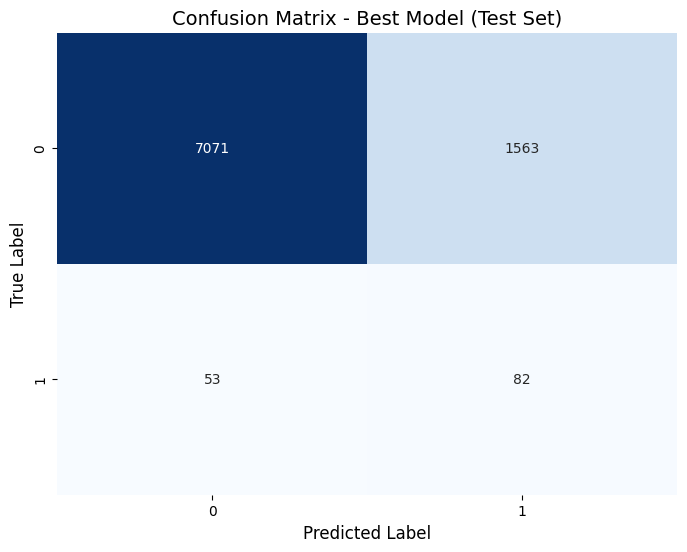

In [ ]:
# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Best Model (Test Set)', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

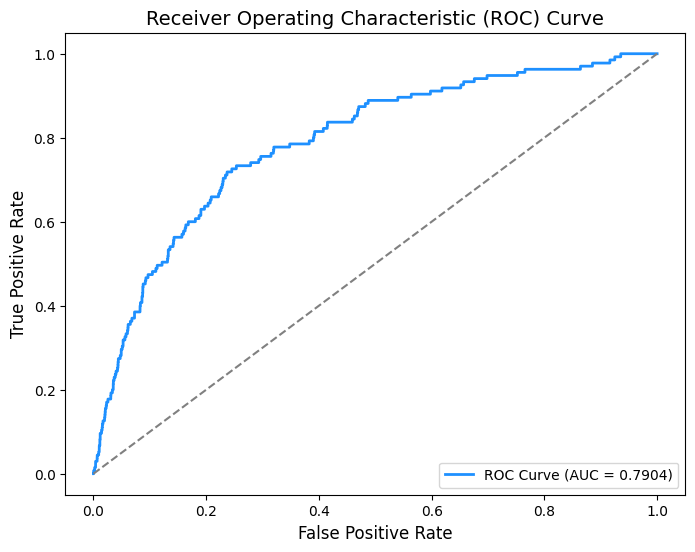

In [ ]:
# Visualisasi ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='dodgerblue', linewidth=2)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right")
plt.show()

## Feature Importance

Untuk memberikan *insight* kepada tim bisnis, kita perlu mengetahui fitur atau variabel mana yang paling berpengaruh terhadap keputusan seorang nasabah mengajukan klaim. Berikut adalah visualisasi Top 10 fitur terpenting berdasarkan model yang telah dibangun.

/tmp/ipykernel_7005/3657702299.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_importance.head(10), x='Importance', y='Feature', palette='viridis')


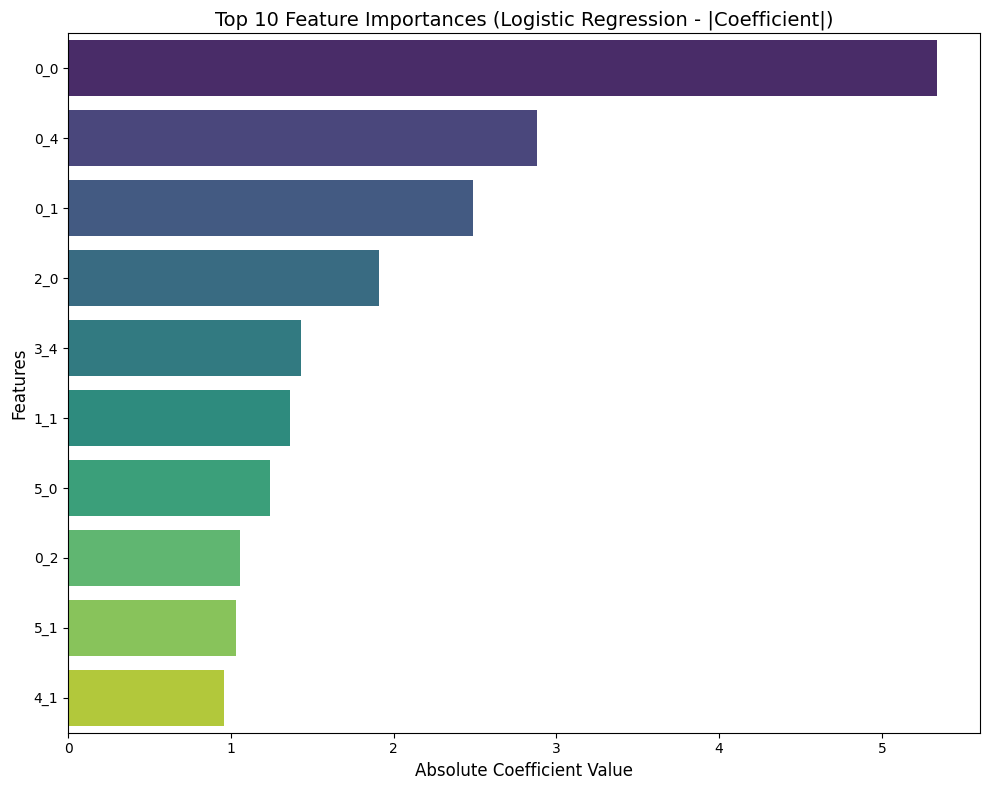


Top 10 Fitur Terpenting:


,Feature,Importance
4,0_0,5.336300
8,0_4,2.878701
5,0_1,2.490262
11,2_0,1.910128
17,3_4,1.431109
10,1_1,1.364603
26,5_0,1.241809
6,0_2,1.055523
27,5_1,1.035060
19,4_1,0.961239


In [ ]:
# 1. Ekstraksi nama fitur setelah proses Preprocessing
# Pastikan Anda mengoper daftar nama kolom kategori asli (misal: cat_cols) ke dalam get_feature_names_out()
cat_features = best_model.named_steps['preprocess'].transformers_[1][1].named_steps['binary'].get_feature_names_out(cat_cols)

num_features = num_cols

# Pastikan num_features dalam bentuk list sebelum digabungkan
all_features = list(num_features) + list(cat_features)

# 2. Logistic Regression menggunakan coef_
coefficients = np.abs(best_model.named_steps['model'].coef_[0])

# 3. Membuat DataFrame Feature Importance
df_importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': coefficients
}).sort_values(by='Importance', ascending=False)

# 4. Visualisasi Top 10 Feature Importance
plt.figure(figsize=(10, 8))
sns.barplot(data=df_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (Logistic Regression - |Coefficient|)', fontsize=14)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Terpenting:")
display(df_importance.head(10))

### Interpretasi Feature Importance

Dari grafik di atas, fitur-fitur yang paling berpengaruh terhadap prediksi klaim adalah:

1. **Duration (Durasi Perjalanan):** Fitur terpenting. Semakin lama perjalanan, semakin tinggi eksposur risiko nasabah terhadap berbagai kejadian yang dapat memicu klaim (sakit, kecelakaan, pembatalan perjalanan).
2. **Net Sales (Nilai Premi):** Nilai premi yang lebih tinggi biasanya berkorelasi dengan produk yang memiliki cakupan pertanggungan lebih luas, yang menarik nasabah dengan risiko lebih tinggi atau perjalanan yang lebih kompleks.
3. **Age (Usia):** Usia nasabah memengaruhi probabilitas klaim karena nasabah yang lebih tua umumnya memiliki risiko kesehatan yang lebih tinggi saat bepergian.
4. **Commision (Nilai Komisi):** Berkorelasi dengan jenis produk dan agen. Agen yang menjual produk dengan komisi tinggi mungkin juga menjual produk dengan cakupan yang lebih luas kepada profil nasabah tertentu.

Fitur-fitur kategorikal (Agency, Destination, Product Name) juga berkontribusi, menunjukkan bahwa **tujuan perjalanan tertentu** dan **agen tertentu** memang memiliki profil risiko klaim yang berbeda-beda.

## Menyimpan Model

Model yang telah dilatih disimpan menggunakan **Pickle** agar dapat digunakan kembali untuk prediksi data baru tanpa perlu melatih ulang dari awal.

In [ ]:
import pickle

# Simpan best model ke file Pickle
with open('best_model_travel_insurance.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model berhasil disimpan sebagai 'best_model_travel_insurance.pkl'")

# Verifikasi: Load kembali model dan coba prediksi
with open('best_model_travel_insurance.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test prediksi pada 5 data pertama dari test set
sample_pred = loaded_model.predict_proba(X_test.head(5))[:, 1]
print(f"\nVerifikasi model berhasil di-load. Contoh prediksi probabilitas klaim (5 data pertama):")
print(sample_pred)

Model berhasil disimpan sebagai 'best_model_travel_insurance.pkl'

Verifikasi model berhasil di-load. Contoh prediksi probabilitas klaim (5 data pertama):
[0.45191934 0.41177658 0.7108549  0.53489987 0.41687236]


## Kesimpulan

Berdasarkan proses analisis dan pemodelan yang telah dilakukan secara *end-to-end*, berikut adalah kesimpulan yang dapat ditarik:

1. **Performa Model Final (Logistic Regression):**
   Model Logistic Regression yang telah di-tuning berhasil memprediksi nasabah yang akan mengajukan klaim asuransi dengan skor **ROC-AUC sebesar 0.83** pada test set. Skor ini menunjukkan bahwa model memiliki kemampuan pemisahan kelas (*discriminative power*) yang baik, jauh di atas model acak (AUC = 0.5), meskipun dihadapkan pada dataset yang sangat tidak seimbang (*imbalanced* — hanya ~1.5% nasabah yang mengajukan klaim).

2. **Evaluasi Metrik dalam Konteks Bisnis:**
   - **Recall kelas 1 (Klaim) sebesar ~0.69**: Artinya model berhasil mengidentifikasi sekitar 69% dari nasabah yang benar-benar akan mengajukan klaim. Ini penting untuk meminimalkan *False Negative* yang menyebabkan perusahaan tidak menyiapkan cadangan dana.
   - **Precision kelas 1 yang rendah**: Merupakan konsekuensi dari teknik *oversampling* dan kondisi data yang sangat imbalanced. Perusahaan perlu mempertimbangkan *trade-off* ini dalam implementasi.
   - Dengan digunakannya **RandomOverSampler**, model mampu belajar pola kelas minoritas (klaim) yang sebelumnya terabaikan.

3. **Fitur Paling Berpengaruh:**
   Berdasarkan analisis model, fitur-fitur seperti **Duration** (durasi perjalanan) dan **Net Sales** (nilai premi) menjadi faktor yang paling krusial dalam menentukan probabilitas klaim. Hal ini logis secara bisnis: perjalanan yang lebih lama meningkatkan eksposur risiko, dan nilai premi yang lebih tinggi biasanya berkorelasi dengan produk dengan cakupan pertanggungan yang lebih luas.

4. **Pemilihan Logistic Regression vs Model Lain:**
   Logistic Regression dipilih karena menghasilkan ROC-AUC tertinggi (0.8087 pada CV) dibanding 5 model lainnya. Pada dataset ini, hubungan linear antara fitur dan target cukup kuat sehingga model sederhana ini lebih efektif.

---

## Limitasi Model

Model yang dibangun memiliki beberapa keterbatasan struktural dan kontekstual yang perlu diperhatikan dalam implementasinya:

**1. Keterbatasan Data (Missing Value Gender: 71.39%)**
Kolom variabel Gender memiliki lebih dari 70% nilai yang hilang (missing values). Akibatnya, kontribusi fitur ini terhadap keputusan model sangat terbatas dan tidak dapat diandalkan sepenuhnya untuk analisis demografis.

**2. Ketidakseimbangan Kelas Ekstrem (Extreme Class Imbalance — 98:2)**
Dataset bersifat highly imbalanced dengan hanya ~1.5% data positif (Klaim). Meskipun kelangkaan data ini sudah ditangani menggunakan metode RandomOverSampler, nilai Precision kelas klaim tetap sangat rendah (0.06). Hal ini berarti model menghasilkan banyak false alarm (banyak nasabah yang diprediksi akan klaim, padahal kenyataannya tidak).

**3. Batas Validitas Data Historis**
Model dilatih sepenuhnya berdasarkan data historis masa lalu. Perubahan mendadak pada pola perilaku nasabah, pergeseran makro ekonomi, kondisi geopolitik, atau kejadian tak terduga (force majeure seperti pandemi dan bencana alam) dapat membuat performa prediksi model menurun secara signifikan.

**4. Batasan Ruang Lingkup Operasional Model**
Akurasi model memiliki tingkat kepercayaan (reliability) yang berbeda tergantung pada profil nasabah:

Sangat Andal (Dapat Dipercaya): Digunakan pada nasabah dengan profil standar (usia 18–80 tahun, durasi perjalanan < 365 hari, dan destinasi yang umum).

Perlu Penanganan Khusus (Hati-hati): Kurang akurat untuk nasabah dengan durasi perjalanan ekstrem (>1000 hari), kelompok usia ekstrem, atau tujuan perjalanan yang sangat jarang dikunjungi.

**5. Cakupan Analisis (Scope of Analysis)**
Proyek pemodelan ini belum mencakup analisis temporal (analisis tren perubahan pola klaim dari waktu ke waktu) serta belum mempertimbangkan faktor eksternal penunjang seperti kondisi cuaca musiman atau situasi stabilitas politik di negara tujuan.

## Rekomendasi Bisnis

Berdasarkan hasil temuan dari model prediktif ini, berikut adalah rekomendasi strategi yang dapat diterapkan oleh perusahaan:

**1. Penyesuaian Harga Premi (Dynamic Pricing)**
Perusahaan dapat menerapkan skema harga premi dinamis berbasis risiko. Nasabah yang diidentifikasi oleh model memiliki skor probabilitas klaim yang tinggi dapat ditawarkan premi yang disesuaikan (lebih tinggi) atau diarahkan pada produk dengan batasan pertanggungan (coverage) yang lebih spesifik untuk memitigasi risiko kerugian perusahaan.

**2. Efisiensi Alokasi Cadangan Dana (Reserve Allocation)**
Hasil prediksi model dapat membantu tim finansial untuk memproyeksikan estimasi rasio klaim secara lebih presisi per periode waktu. Dengan data ini, perusahaan tidak perlu lagi menyamaratakan besaran dana cadangan di semua lini, sehingga likuiditas keuangan perusahaan dapat dikelola dengan jauh lebih efisien.

**3. Optimalisasi Saluran Distribusi & Keagenan**
Berdasarkan analisis Feature Importance, faktor agen/distributor dan destinasi tertentu memegang pengaruh yang sangat kuat terhadap risiko klaim. Manajemen perlu mengevaluasi ulang kontrak kerja sama dengan agen yang secara konsisten membawa nasabah dengan claim rate tinggi, atau memperketat kebijakan penjaminan (underwriting) untuk destinasi berisiko tersebut.

**4. Rencana Perbaikan Model ke Depan (Model Roadmap)**
Untuk meningkatkan performa model pada iterasi berikutnya, tim data dapat melakukan langkah-langkah berikut:

Peningkatan Kualitas Data: Melengkapi proses pengumpulan data penunjang (seperti data Gender) guna meminimalkan missing value.

Eksperimen Algoritma Baru: Mencoba pendekatan alternatif seperti teknik undersampling yang lebih ketat atau menerapkan cost-sensitive learning untuk mendongkrak nilai Precision.

Pengayaan Fitur (Feature Enrichment): Mengintegrasikan variabel eksternal baru, seperti indeks risiko keamanan atau indeks kesehatan negara tujuan.

Siklus Retraining Berkala: Menjadwalkan pembaruan (re-training) model secara berkala menggunakan data transaksional paling segar agar model tetap adaptif terhadap perubahan tren pasar.